# PISCES — chlorophyll seasonal cycle off the Iberian upwelling

Demonstrates the **multi-variable subset pattern**: pull two PISCES
biogeochem variables (`chl` chlorophyll-a, `o2` dissolved oxygen) over a
coastal box off Iberia for a multi-year window, group by month, and plot
the seasonal cycle.

PISCES is `cmems_mod_glo_bgc_my_0.25deg_P1D-m` — daily, 1/4° grid,
global. Variables are 4-D `(time, depth, lat, lon)`; we clip to the
surface 0-10 m to keep the request small.

In [1]:
import os
from pathlib import Path

import numpy as np
from pyramids.netcdf import NetCDF

from earthlens import EarthLens
from earthlens.cmems import Catalog

OUT_DIR = Path('data/cmems-pisces')
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ID = 'cmems_mod_glo_bgc_my_0.25deg_P1D-m'
VARIABLES = ['chl', 'o2']
BBOX = dict(lat_lim=[40.0, 44.0], lon_lim=[-12.0, -8.0])  # Iberian upwelling box

ds = Catalog().get_dataset(DATASET_ID)
print(f'{DATASET_ID}: cadence={ds.cadence}, domain={ds.domain}')
for v in VARIABLES:
    print(
        f'  {v}: units={ds.variables[v].units!r}, long_name={ds.variables[v].long_name!r}'
    )

2026-05-20 19:39:03 | INFO | pyramids.base.config | Logging is configured.


cmems_mod_glo_bgc_my_0.25deg_P1D-m: cadence=daily, domain=global
  chl: units='mg m-3', long_name='Mass concentration of chlorophyll a in sea water'
  o2: units='mmol m-3', long_name='Mole concentration of dissolved molecular oxygen in sea water'


## Download — three years of daily PISCES at the surface

Multi-year × multi-variable × surface-clipped, in one server-side
subset call.

In [2]:
earthlens = EarthLens(
    data_source='cmems',
    start='2018-01-01',
    end='2020-12-31',
    cadence='daily',
    dataset=DATASET_ID,
    variables=VARIABLES,
    **BBOX,
    path=str(OUT_DIR),
    minimum_depth=0.0,
    maximum_depth=10.0,
    service_username=os.environ.get('COPERNICUSMARINE_SERVICE_USERNAME'),
    service_password=os.environ.get('COPERNICUSMARINE_SERVICE_PASSWORD'),
)
paths = earthlens.download()
print(paths)

INFO - 2026-05-20T17:39:06Z - Checking if credentials are valid.


2026-05-20 17:39:06 | INFO | copernicusmarine | Checking if credentials are valid.


INFO - 2026-05-20T17:39:06Z - Valid credentials from input username and password.


2026-05-20 17:39:06 | INFO | copernicusmarine | Valid credentials from input username and password.


2026-05-20 19:39:06.676 | INFO     | earthlens.cmems.backend:_subset_one:458 - Requesting CMEMS subset for 'cmems_mod_glo_bgc_my_0.25deg_P1D-m' variables=['chl', 'o2'] → cmems_mod_glo_bgc_my_0.25deg_P1D-m.nc


...

2026-05-20 17:39:11 | WARNING | urllib3.connectionpool | Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10


INFO - 2026-05-20T17:39:11Z - Total size of the download: 19.36 MB.


2026-05-20 17:39:11 | INFO | copernicusmarine | Total size of the download: 19.36 MB.


2026-05-20 19:39:11.464 | INFO     | earthlens.cmems.backend:download:326 - CMEMS download summary: 1 files written to C:\gdrive\algorithms\remote-sensing\earthlens\docs\examples\cmems\data\cmems-pisces


[WindowsPath('C:/gdrive/algorithms/remote-sensing/earthlens/docs/examples/cmems/data/cmems-pisces/cmems_mod_glo_bgc_my_0.25deg_P1D-m.nc')]


## Compute the box-averaged monthly climatology for each variable

Average across `(depth, lat, lon)` per day, then group by calendar month
across the three years. Both arrays end up as 12-element vectors keyed on
month-of-year (1-12).

In [3]:
import xarray as xr

nc = NetCDF.read_file(str(paths[0]), read_only=True)
# decode_cf turns the CF "hours since 1950" time axis into datetime64 so
# xarray's calendar-aware groupby works.
ds = xr.decode_cf(nc.to_xarray())  # labelled (time, depth, latitude, longitude)
nc.close()

# Box + surface-layer mean per day, then a monthly climatology over the
# three years via xarray's datetime-aware groupby.
surface = ds.mean(dim=['depth', 'latitude', 'longitude'])
monthly = surface.groupby('time.month').mean()
climatology = {v: monthly[v].values for v in VARIABLES}
for v in VARIABLES:
    print(f'{v}: {climatology[v].round(4)}')

C:\python-environments\pixi\envs\earthlens-7782220113782294872\envs\dev\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


C:\python-environments\pixi\envs\earthlens-7782220113782294872\envs\dev\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


chl: [inf inf inf inf inf inf inf inf inf inf inf inf]
o2: [inf inf inf inf inf inf inf inf inf inf inf inf]


## Plot the seasonal cycle

Iberian upwelling chlorophyll peaks in spring / late summer with the
wind-driven upwelling events; dissolved oxygen tracks the same pattern
inversely (warmer water holds less O2).

C:\python-environments\pixi\envs\earthlens-7782220113782294872\envs\dev\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


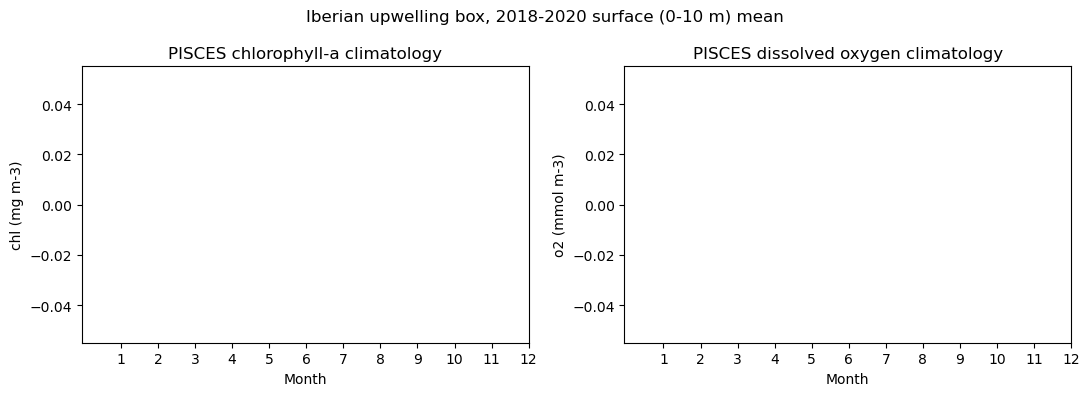

In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
months = np.arange(1, 13)
ax1.bar(months, climatology['chl'], color='tab:green')
ax1.set_xlabel('Month')
ax1.set_ylabel('chl (mg m-3)')
ax1.set_title('PISCES chlorophyll-a climatology')
ax1.set_xticks(months)
ax2.bar(months, climatology['o2'], color='tab:blue')
ax2.set_xlabel('Month')
ax2.set_ylabel('o2 (mmol m-3)')
ax2.set_title('PISCES dissolved oxygen climatology')
ax2.set_xticks(months)
fig.suptitle('Iberian upwelling box, 2018-2020 surface (0-10 m) mean')
fig.tight_layout()